In [2]:
import pandas as pd

df = pd.read_csv('bank-full.csv', sep=';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
#Understanding the dataset (Shape, Datatypes, check numerical and categorial cloumns etc) and checking for Missing Values

In [5]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of Dataset:
(45211, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  in

In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


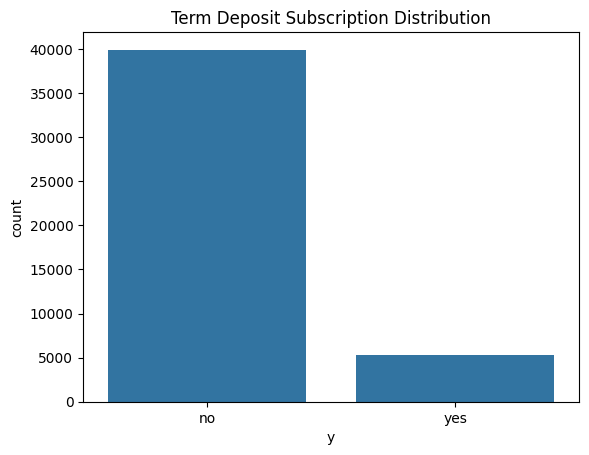

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='y', data=df)

plt.title("Term Deposit Subscription Distribution")
plt.show()


#shows the dataset is highly imbalancing as No are almost 40000 and yes are near 5000 which can effect the model training

In [9]:
df['y'].value_counts(normalize=True)*100

,proportion
y,
no,88.30152
yes,11.69848


In [10]:
#The target variable is highly imbalanced.
#88% of customers did not subscribe to deposit, and only 12% subscribed.

In [11]:
#EDA:

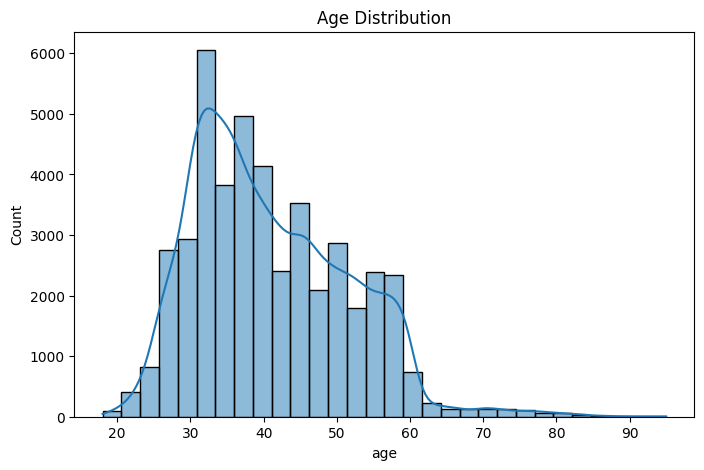

In [12]:
#Age Distribution:

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


#customers are mostly between age 30 to 50 years old and very less customers are above 60 to 90

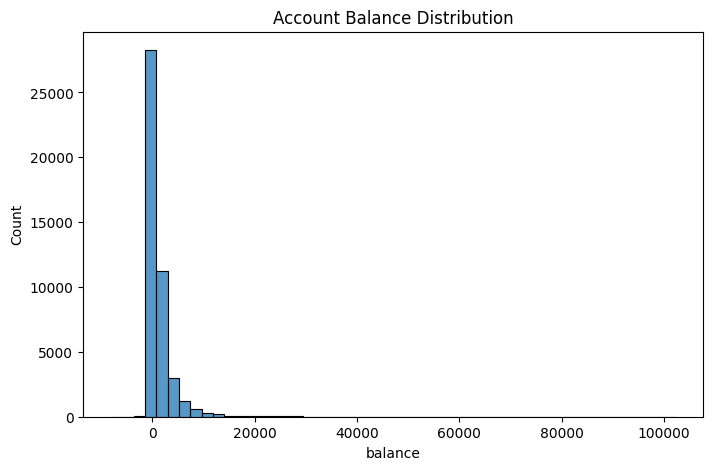

In [13]:
#Balance Distribution:

plt.figure(figsize=(8,5))
sns.histplot(df['balance'], bins=50)
plt.title("Account Balance Distribution")
plt.show()

#Mostly we can see customers have low balance and a very few have high balance. Data is highly skewed.

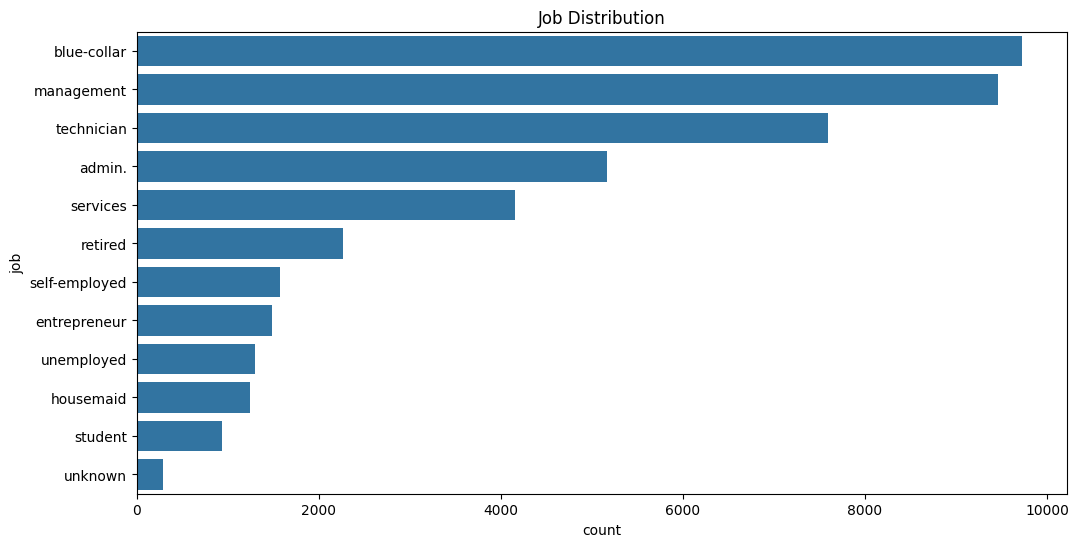

In [14]:
#Job Distribution:

plt.figure(figsize=(12,6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title("Job Distribution")
plt.show()

#Blue collars are the most with management and technitian while student and unknow are the least

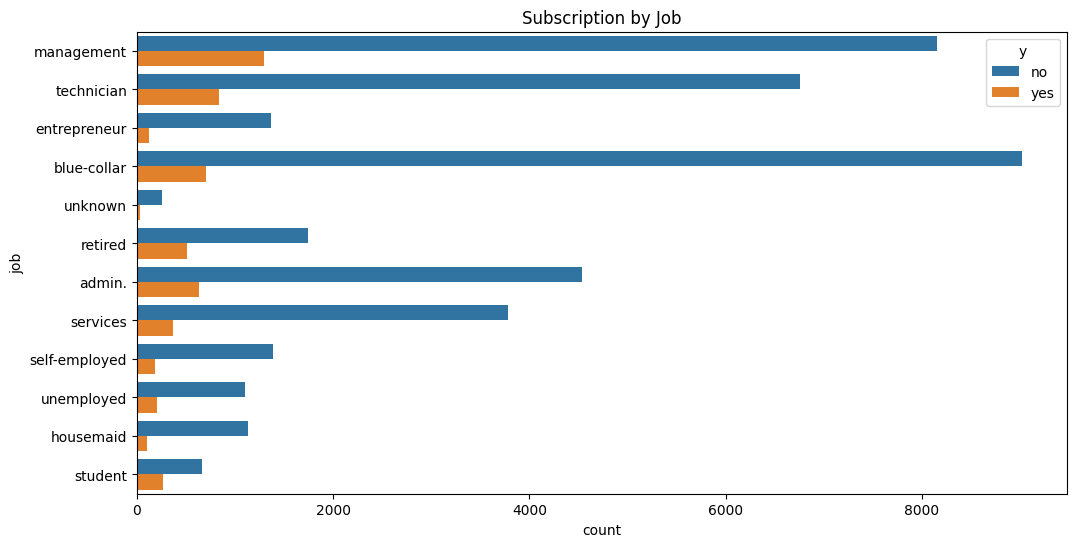

In [15]:
#Subscription by Job:

plt.figure(figsize=(12,6))
sns.countplot(y='job', hue='y', data=df)
plt.title("Subscription by Job")
plt.show()

#Management has most of the subscriptns while blue collar was the most with job but  have vert lesser susbscriptn compared to it.

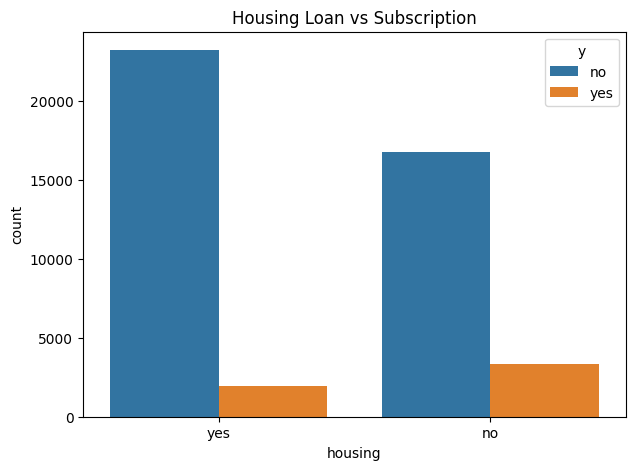

In [16]:
#Housing Loan vs Subscription:

plt.figure(figsize=(7,5))
sns.countplot(x='housing', hue='y', data=df)
plt.title("Housing Loan vs Subscription")
plt.show()


# the subscriptns are very much higher with non housing loans customers.

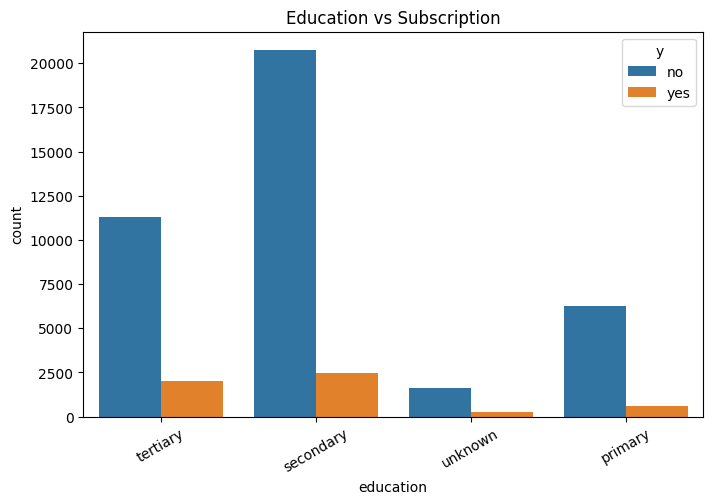

In [17]:
#Education vs Subscription:

plt.figure(figsize=(8,5))
sns.countplot(x='education', hue='y', data=df)
plt.title("Education vs Subscription")
plt.xticks(rotation=30)
plt.show()

#tertiary educated person subscribe the most but secondary dominates the overall but they are way more than the terirary in numbers.

In [18]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

In [19]:
#married customer are more then the divorced and single so they dominate the overall dataset.
#customer with Default credit are way less then the non. showing high imblaned dataset'
#contact method are mostly cellular used by the bank
#previous campaign are mostly unknown of the customers and the known one have very less success (1511)

In [20]:
# Check unknown values in categorical columns

for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col}: {unknown_count}")

job: 288
marital: 0
education: 1857
default: 0
housing: 0
loan: 0
contact: 13020
month: 0
poutcome: 36959
y: 0


In [21]:
#it doesnt have null values but several column have unknown have to fix those as they are missing or unavaliable information


In [22]:
#Encoding the yes and no as 0 and 1 so that we can train it as ML doesnt understand anything else than numbers.

In [23]:
# Encode target variable

df['y'] = df['y'].map({'yes':1, 'no':0})

# Verify encoding
df['y'].head()

,y
0,0
1,0
2,0
3,0
4,0


In [24]:
#separtaing Feature and Target Variable:

# Separate independent and dependent variables

X = df.drop('y', axis=1)
y = df['y']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (45211, 16)
Target Shape: (45211,)


In [25]:
#Hot Encoding: As ML cant understand text and many column have text values so convert them into numerical values.

# Example:
# Job_Management = 1
# Job_Technician = 0


# Convert categorical variables into numerical variables

X = pd.get_dummies(X, drop_first=True)

print("Encoded Dataset Shape:")
print(X.shape)

Encoded Dataset Shape:
(45211, 42)


In [26]:
#split data for training:

#80% for training and 20% for testing.


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (36168, 42)
Testing Data: (9043, 42)


In [27]:
#Loaded and trained the logisticRegression model on 1000 iteration as it is a classifcation problem and predicts the customer suscriptn probablity.

from sklearn.linear_model import LogisticRegression

# Create model

lr_model = LogisticRegression(max_iter=1000)

# Train model

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [28]:
# Make predictions

lr_predictions = lr_model.predict(X_test)

# Probability predictions

lr_probabilities = lr_model.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

#predicted 90% of the customers accurately
#about 64% times the model is correct that the customer will subscribe.
#recall  is low at 33.65% tells that the model fails to identify a large number of actual subscribers.
#The F1-score of 44.22% is the balance between precision and recall, showing lowr value due to model cant predict postive subscriptn cases properly

Accuracy : 0.9006966714585868
Precision: 0.644927536231884
Recall   : 0.33648393194706994
F1 Score : 0.4422360248447205


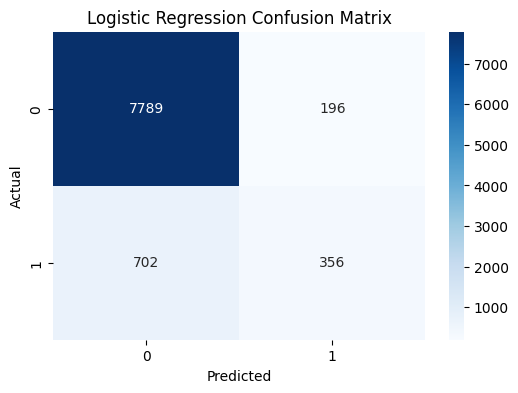

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#The confusion matrix shows that the model correctly identified 7,789 non-subscribers and 356 subscribers.
#it failed to detect 702 actual subscribers and result it a  low recall score

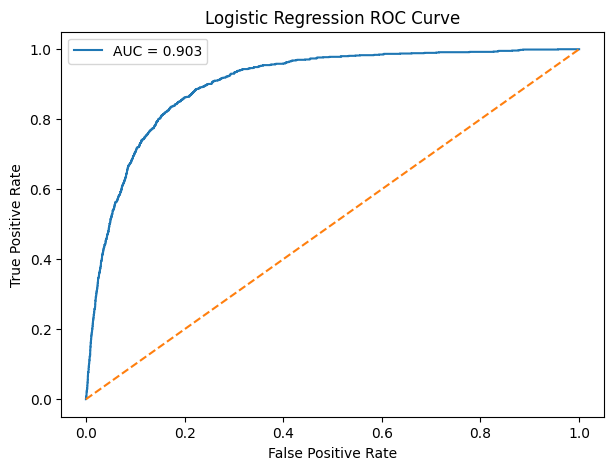

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, lr_probabilities)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc_score(y_test, lr_probabilities):.3f}")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

#The ROC-AUC score of 0.903 demonstrates excellent discriminative ability.
#The model can easily distinguish between customers who are likely to subscribe and those who are not

In [32]:
#Applying Random Forest:

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [33]:
# Predictions

rf_predictions = rf_model.predict(X_test)

# Probability predictions

rf_probabilities = rf_model.predict_proba(X_test)[:,1]

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Random Forest Results")
print("---------------------")

print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy : 0.9058940617051864
Precision: 0.6666666666666666
Recall   : 0.391304347826087
F1 Score : 0.4931506849315068


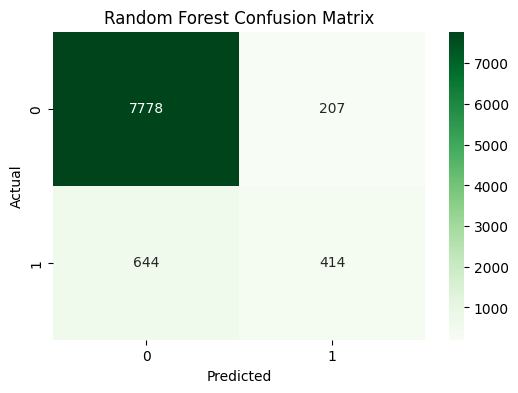

In [35]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

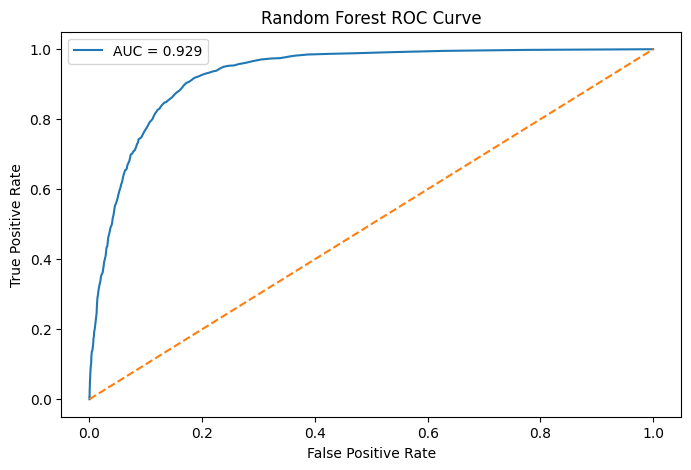

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(8,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {roc_auc_score(y_test, rf_probabilities):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [37]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,duration,0.273597
1,balance,0.101476
0,age,0.097108
2,day,0.087650
40,poutcome_success,0.053981
5,pdays,0.040838
4,campaign,0.039586
24,housing_yes,0.021578
6,previous,0.020597
27,contact_unknown,0.013923


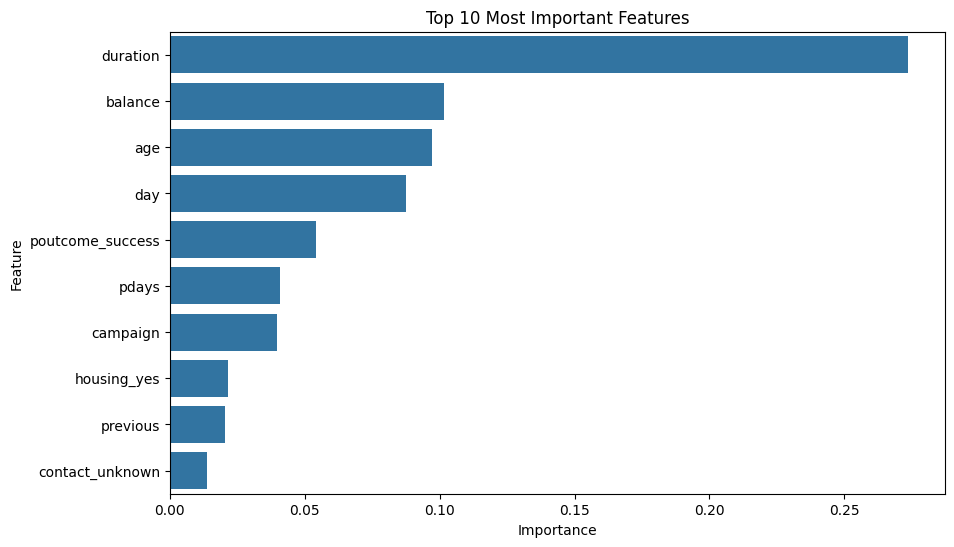

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Most Important Features")
plt.show()

In [39]:
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],

    'Logistic Regression':[
        accuracy_score(y_test, lr_predictions),
        precision_score(y_test, lr_predictions),
        recall_score(y_test, lr_predictions),
        f1_score(y_test, lr_predictions),
        roc_auc_score(y_test, lr_probabilities)
    ],

    'Random Forest':[
        accuracy_score(y_test, rf_predictions),
        precision_score(y_test, rf_predictions),
        recall_score(y_test, rf_predictions),
        f1_score(y_test, rf_predictions),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.900697,0.905894
1,Precision,0.644928,0.666667
2,Recall,0.336484,0.391304
3,F1 Score,0.442236,0.493151
4,ROC-AUC,0.903291,0.929192


In [40]:
#Comparison:


#Random Forest performed better than Logistic Regression on all evaluation metrics.

#Accuracy increased from 90.07% to 90.59%.

#Precision increased from 64.49% to 66.67%, which means Random Forest made more correct positive predictions.

#Recall improved from 33.65% to 39.13%, meaning Random Forest identified more actual subscribers.

#F1-Score increased from 44.22% to 49.32%, showing a better balance between Precision and Recall.

#ROC-AUC improved from 0.903 to 0.929, indicating better ability to distinguish between subscribers and non-subscribers.

#Random Forest correctly identified 414 subscribers compared to 356 identified by Logistic Regression.

#Since the main goal is to identify customers likely to subscribe, Random Forest is the preferred model for this project.

#Final Model = Random Forest.

In [41]:
!pip install shap

In [42]:
import shap
print(shap.__version__)

0.52.0


In [43]:
import shap

# Take only 200 samples
X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

In [44]:
print(type(shap_values))

<class 'numpy.ndarray'>


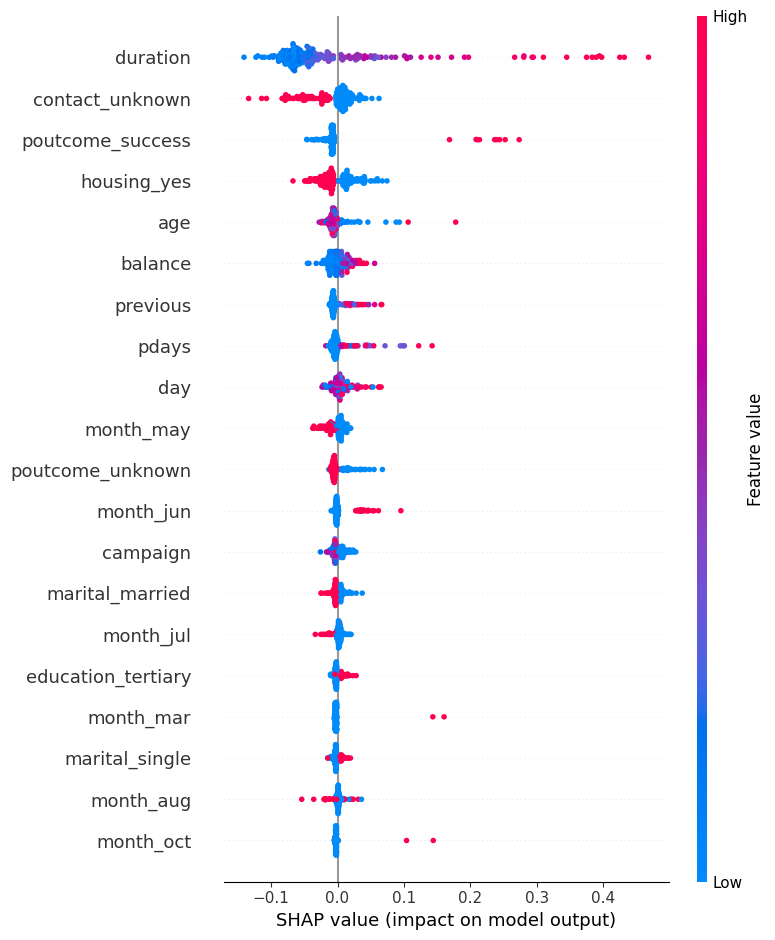

In [46]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample
)


# SHAP Summary Plot shows how each feature influences the prediction across all customers.
# Features at the top have the strongest impact on the model's decisions.

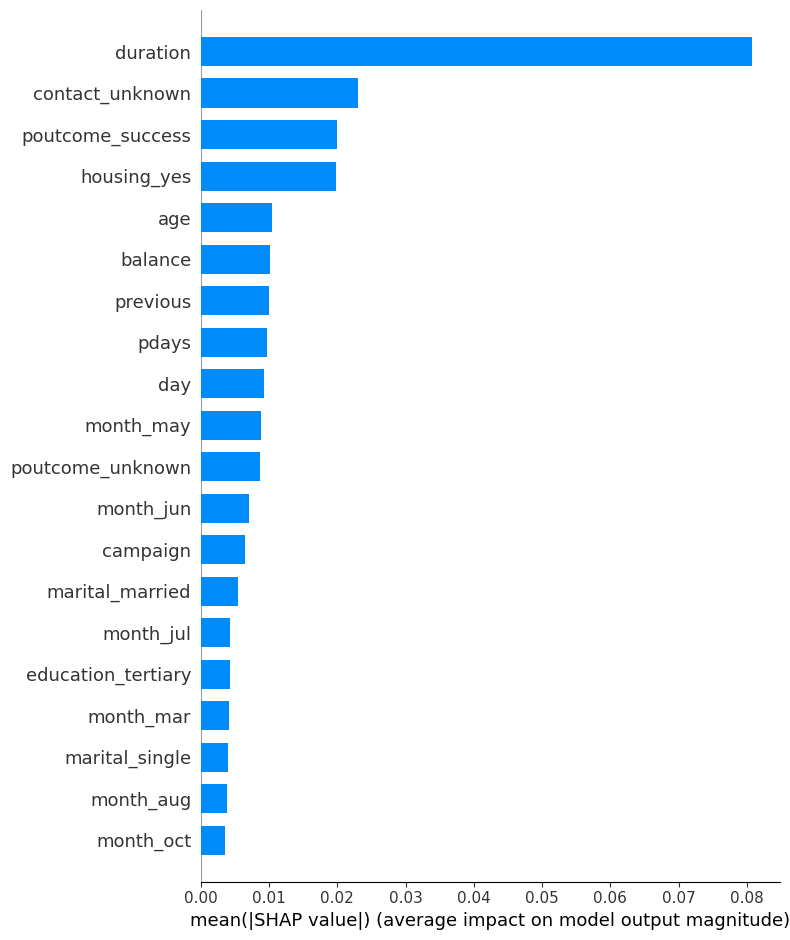

In [47]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

#the SHAP Bar Plot ranks features based on their overall contribution to the model.
#Higher values indicate more important features.

In [ ]:
# SHAP Summary Plot shows the overall impact of features on model predictions:

# Call duration is the most influential feature, followed by contact type, previous campaign success, housing loan status, and age.
# Features appearing at the top have the strongest impact on customer subscription predictions.

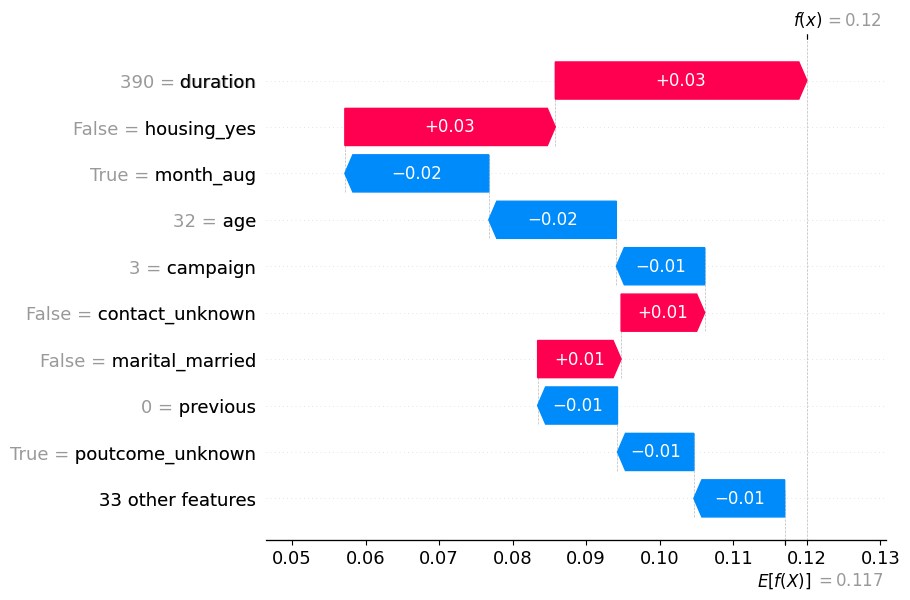

In [48]:
#Individual Customers:

#1st Customer:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[0],
        feature_names=X_sample.columns
    )
)

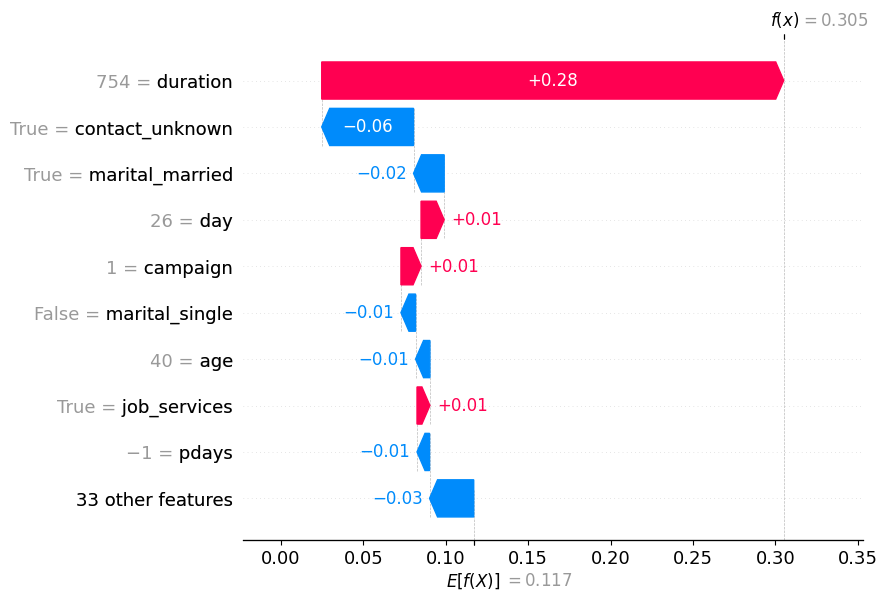

In [49]:
#2nd Customer:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10,:,1],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[10],
        feature_names=X_sample.columns
    )
)

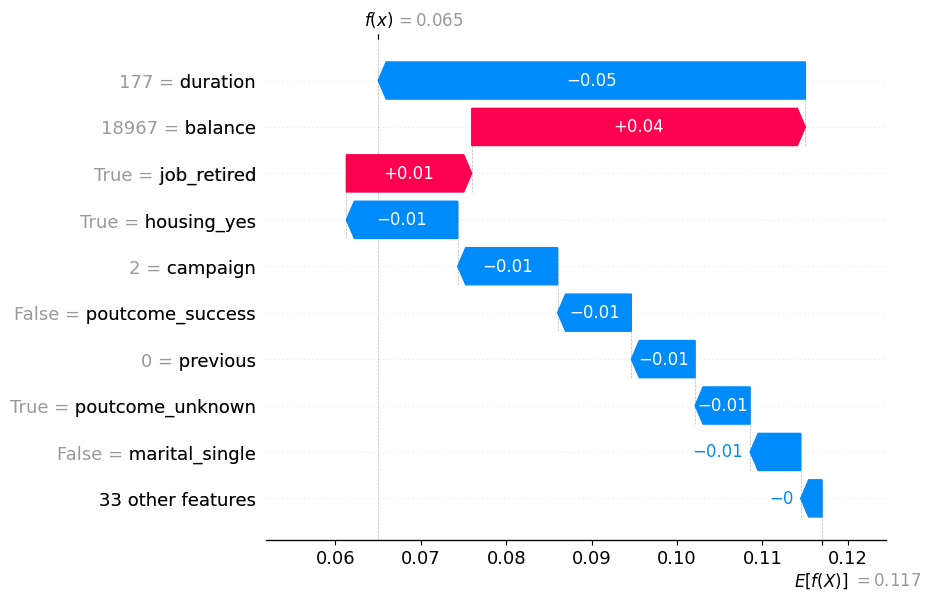

In [50]:
#3rd Customer:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[20,:,1],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[20],
        feature_names=X_sample.columns
    )
)

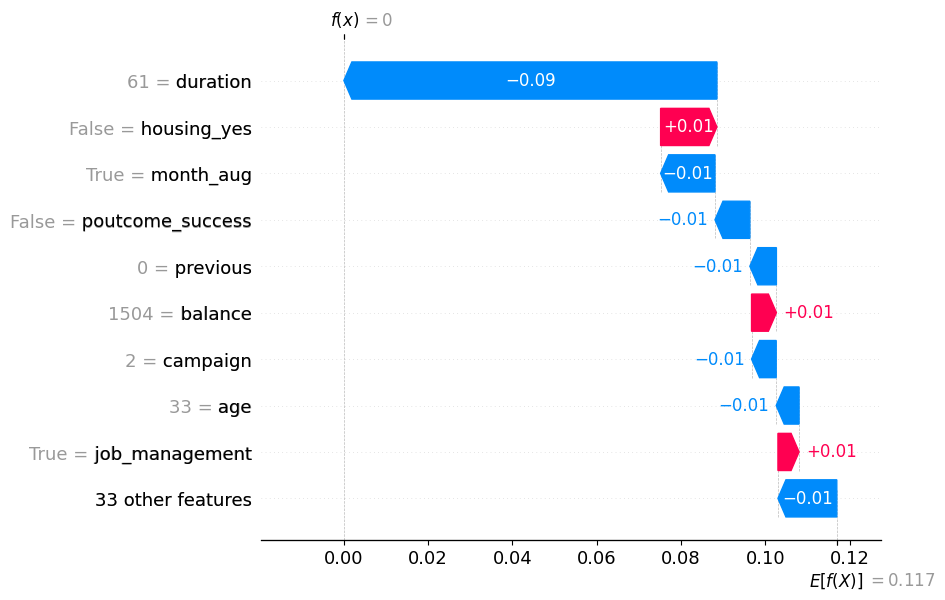

In [51]:
#4th Customer:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[30,:,1],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[30],
        feature_names=X_sample.columns
    )
)

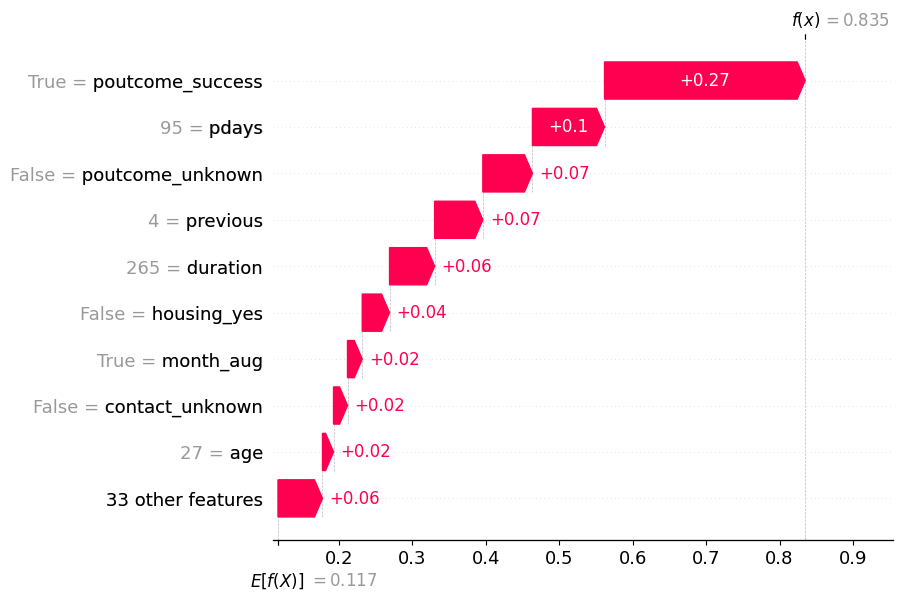

In [53]:
#5th Customer:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[40,:,1],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[40],
        feature_names=X_sample.columns
    )
)

In [54]:
# Customer 5 Analysis

# Final predicted probability = 83.5%

# Positive factors:
# - Previous campaign success had the strongest impact.
# - Previous contacts increased probability.
# - Longer call duration increased probability.
# - No housing loan increased probability.

# Negative factors:
# - Very few negative contributions were observed.

# The model predicts a high likelihood of subscription
# because multiple important features contributed positively.

In [ ]:
#Business Insight:

1. Call duration is the most influential factor affecting customer subscription decisions.

2. Customers with higher account balances are generally more likely to subscribe to term deposits.

3. Customers without housing loans show a greater tendency to invest in term deposits.

4. Previous campaign success strongly increases the likelihood of future subscriptions.

5. Customer age also influences subscription behavior and should be considered during marketing campaigns.

6. Random Forest identified more potential subscribers than Logistic Regression, making it more suitable for targeted marketing.

7. Banks can reduce marketing costs by focusing on customers with characteristics associated with higher subscription probabilities.
